In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Define the Communication Autoencoder
class WirelessAutoencoder(nn.Module):
    def __init__(self, M, n_channel_dims):
        super(WirelessAutoencoder, self).__init__()
        self.M = M
        self.n_dims = n_channel_dims
        
        # Transmitter (Encoder)
        self.encoder = nn.Sequential(
            nn.Linear(self.M, self.M),
            nn.ReLU(),
            nn.Linear(self.M, self.n_dims) 
        )
        
        # Receiver (Decoder)
        self.decoder = nn.Sequential(
            nn.Linear(self.n_dims, self.M),
            nn.ReLU(),
            nn.Linear(self.M, self.M)
        )
        
    def forward(self, x, noise_variance):
        # 1. Encode message to channel symbols
        s = self.encoder(x)
        
        # 2. Normalization layer (Energy constraint: average power = 1)
        # Crucial for wireless simulations so the model doesn't cheat by boosting power to infinity!
        s_norm = np.sqrt(self.n_dims) * (s / torch.norm(s, p=2, dim=1, keepdim=True))
        
        # 3. Channel Layer: Additive White Gaussian Noise (AWGN)
        noise = torch.randn_like(s_norm) * np.sqrt(noise_variance)
        r = s_norm + noise
        
        # 4. Decode received symbols back to message probabilities
        y = self.decoder(r)
        return y, s_norm

In [2]:
# System Parameters
M = 16       # 16 possible messages
n_dims = 2   # 2 channel dimensions (I and Q)
NUM_SAMPLES = 80000
BATCH_SIZE = 1024
EPOCHS = 50

# Create one-hot encoded dataset representing random messages
# E.g., message 3 out of 16 becomes [0, 0, 0, 1, 0, ..., 0]
random_labels = torch.randint(0, M, (NUM_SAMPLES,))
data_onehot = torch.nn.functional.one_hot(random_labels, num_classes=M).float()

# Initialize Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WirelessAutoencoder(M, n_dims).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Set fixed training noise variance (equivalent to ~7dB Eb/N0)
training_noise_var = 0.05 

print("Starting Training...")
model.train()
for epoch in range(EPOCHS):
    permutation = torch.randperm(data_onehot.size(0))
    epoch_loss = 0
    
    for i in range(0, data_onehot.size(0), BATCH_SIZE):
        indices = permutation[i:i+BATCH_SIZE]
        batch_x = data_onehot[indices].to(device)
        batch_y_labels = random_labels[indices].to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(batch_x, training_noise_var)
        loss = criterion(outputs, batch_y_labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss/(NUM_SAMPLES/BATCH_SIZE):.4f}")
print("Training Complete!")

Starting Training...
Epoch [1/50], Loss: 2.1018
Epoch [2/50], Loss: 1.0298
Epoch [3/50], Loss: 0.7617
Epoch [4/50], Loss: 0.6445
Epoch [5/50], Loss: 0.5924
Epoch [6/50], Loss: 0.5662
Epoch [7/50], Loss: 0.5495
Epoch [8/50], Loss: 0.5451
Epoch [9/50], Loss: 0.5408
Epoch [10/50], Loss: 0.5390
Epoch [11/50], Loss: 0.5346
Epoch [12/50], Loss: 0.5366
Epoch [13/50], Loss: 0.5345
Epoch [14/50], Loss: 0.5326
Epoch [15/50], Loss: 0.5320
Epoch [16/50], Loss: 0.5308
Epoch [17/50], Loss: 0.5332
Epoch [18/50], Loss: 0.5307
Epoch [19/50], Loss: 0.5340
Epoch [20/50], Loss: 0.5339
Epoch [21/50], Loss: 0.5353
Epoch [22/50], Loss: 0.5320
Epoch [23/50], Loss: 0.5340
Epoch [24/50], Loss: 0.5270
Epoch [25/50], Loss: 0.5333
Epoch [26/50], Loss: 0.5295
Epoch [27/50], Loss: 0.5270
Epoch [28/50], Loss: 0.5287
Epoch [29/50], Loss: 0.5283
Epoch [30/50], Loss: 0.5244
Epoch [31/50], Loss: 0.5256
Epoch [32/50], Loss: 0.5318
Epoch [33/50], Loss: 0.5300
Epoch [34/50], Loss: 0.5327
Epoch [35/50], Loss: 0.5332
Epoch [3

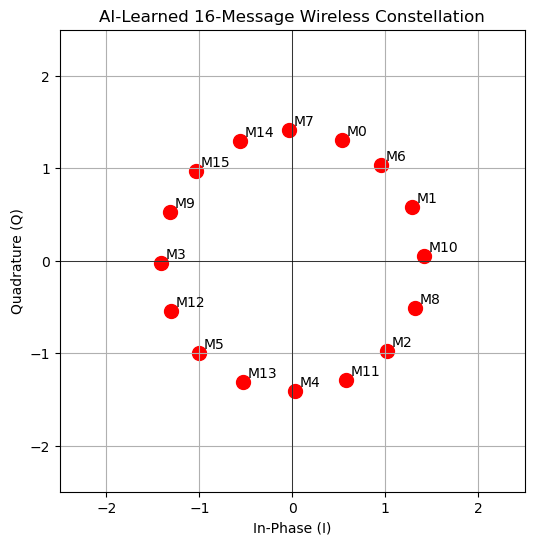

In [3]:
model.eval()
with torch.no_grad():
    # Pass all 16 unique possible messages through the encoder
    test_identity = torch.eye(M).to(device)
    _, transmitted_symbols = model(test_identity, noise_variance=0)
    transmitted_symbols = transmitted_symbols.cpu().numpy()

# Plot the learned geometric constellation
plt.figure(figsize=(6, 6))
plt.scatter(transmitted_symbols[:, 0], transmitted_symbols[:, 1], color='red', marker='o', s=100)
for i in range(M):
    plt.annotate(f"M{i}", (transmitted_symbols[i, 0]+0.05, transmitted_symbols[i, 1]+0.05))
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("AI-Learned 16-Message Wireless Constellation")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.show()

Evaluating BLER performance...
Eb/N0 (dB): -4 | BLER: 0.72477
Eb/N0 (dB): -3 | BLER: 0.69423
Eb/N0 (dB): -2 | BLER: 0.65893
Eb/N0 (dB): -1 | BLER: 0.62199
Eb/N0 (dB):  0 | BLER: 0.58130
Eb/N0 (dB):  1 | BLER: 0.53535
Eb/N0 (dB):  2 | BLER: 0.48657
Eb/N0 (dB):  3 | BLER: 0.43849
Eb/N0 (dB):  4 | BLER: 0.38376
Eb/N0 (dB):  5 | BLER: 0.32829
Eb/N0 (dB):  6 | BLER: 0.26987
Eb/N0 (dB):  7 | BLER: 0.21912
Eb/N0 (dB):  8 | BLER: 0.16827
Eb/N0 (dB):  9 | BLER: 0.12326
Eb/N0 (dB): 10 | BLER: 0.08389


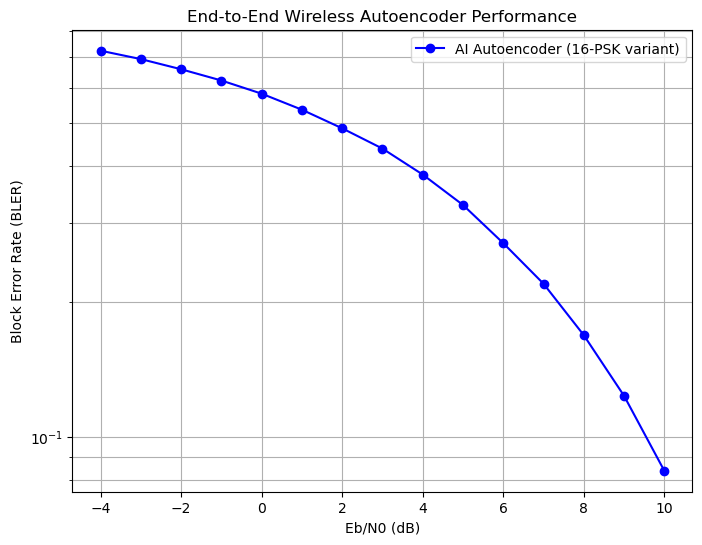

: 

In [ ]:
# %% Evaluation Loop
model.eval()

# Range of Eb/N0 to test (from -4dB to 10dB)
ebn0_db_range = list(range(-4, 11))
bler_results = []

# Calculate bits per message
k = np.log2(M) 

print("Evaluating BLER performance...")
for ebn0_db in ebn0_db_range:
    # Convert Eb/N0 (dB) to noise variance
    # Eb/N0 = (P_signal / P_noise) * (n_dims / k)
    ebn0_linear = 10 ** (ebn0_db / 10.0)
    # Since average power is normalized to 1:
    noise_variance = 1.0 / (2 * ebn0_linear * (k / n_dims))
    
    errors = 0
    test_samples = 100000
    
    with torch.no_grad():
        # Generate random test data
        test_labels = torch.randint(0, M, (test_samples,)).to(device)
        test_x = torch.nn.functional.one_hot(test_labels, num_classes=M).float()
        
        # Pass through the trained autoencoder
        outputs, _ = model(test_x, noise_variance)
        
        # Predict the message index
        predictions = torch.argmax(outputs, dim=1)
        
        # Count mismatches
        errors = (predictions != test_labels).sum().item()
        
    bler = errors / test_samples
    bler_results.append(bler)
    print(f"Eb/N0 (dB): {ebn0_db:2d} | BLER: {bler:.5f}")

# Plot the classic waterfall curve
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_db_range, bler_results, 'b-o', label='AI Autoencoder (16-PSK variant)')
plt.grid(True, which="both", linestyle="-")
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Block Error Rate (BLER)')
plt.title('End-to-End Wireless Autoencoder Performance')
plt.legend()
plt.show()